In [ ]:
!pip install keras-tuner
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report
import numpy as np
import keras_tuner as kt
from sklearn.metrics import classification_report


In [ ]:
# CNN Feature Extractor
def build_cnn_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)  # Output shape: (None, features)

    cnn_model = models.Model(inputs, x, name="CNN_Model")
    return cnn_model

In [ ]:
# Attention Mechanism
def attention_block(inputs):
    attention_scores = layers.Dense(1, activation="tanh")(inputs)  # Compute attention scores
    attention_scores = layers.Softmax()(attention_scores)          # Normalize scores
    attention_output = layers.Multiply()([inputs, attention_scores])  # Apply attention
    return attention_output

In [ ]:
# CNN + Attention Model
def build_cnn_attention_model(input_shape, num_classes):
    cnn_model = build_cnn_model(input_shape)

    # Apply Attention Mechanism
    attention_output = attention_block(cnn_model.output)

    # Fully Connected Layers
    x = layers.Dense(128, activation="relu")(attention_output)
    output = layers.Dense(num_classes, activation="softmax")(x)

    # Define Model
    model = models.Model(inputs=cnn_model.input, outputs=output, name="CNN_Attention_Model")

    return model

In [ ]:
# Define input shape and number of classes
input_shape = (128, 128, 3)
num_classes = 2

In [ ]:
# Build the model
cnn_attention_model = build_cnn_attention_model(input_shape, num_classes)
cnn_attention_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
cnn_attention_model.summary()

Model: "CNN_Attention_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32768)     │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │     32,769 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 1)         │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 32768)     │          0 │ flatten[0][0],    │
│                     │                   │            │ softmax[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │  4,194,432 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 2)         │        258 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,320,707 (16.48 MB)

 Trainable params: 4,320,707 (16.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Install Keras Tuner
!pip install keras-tuner --quiet

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import numpy as np
import keras_tuner as kt

# ✅ Model Builder with Attention + Memory Optimization
def model_builder(hp):
    input_shape = (128, 128, 3)
    num_classes = 2

    inputs = layers.Input(shape=input_shape)

    # CNN Layers
    x = layers.Conv2D(hp.Choice("filters_1", [32, 64]), (3, 3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(hp.Choice("filters_2", [64, 128]), (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(hp.Choice("filters_3", [64, 128, 256]), (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # ✅ Global Average Pooling instead of Flatten
    x = layers.GlobalAveragePooling2D()(x)

    # Attention Mechanism
    attention_scores = layers.Dense(x.shape[-1], activation='tanh')(x)
    attention_probs = layers.Activation('softmax')(attention_scores)
    x = layers.Multiply()([x, attention_probs])

    # Dense and Output Layers
    x = layers.Dense(hp.Choice("dense_units", [64, 128, 256]), activation="relu")(x)
    x = layers.Dropout(hp.Float("dropout_rate", 0.1, 0.4, step=0.1))(x)
    output = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs=inputs, outputs=output)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

# ✅ Synthetic Data Generator with Learnable Patterns
def generate_synthetic_data(n_samples=300, img_shape=(128, 128, 3), num_classes=2):
    labels = np.array([0] * (n_samples // 2) + [1] * (n_samples // 2))
    np.random.shuffle(labels)

    X = np.random.normal(loc=labels[:, None, None, None] * 2.0, scale=1.0, size=(n_samples, *img_shape)).astype(np.float32)
    y = tf.keras.utils.to_categorical(labels, num_classes=num_classes)

    return X, y, labels

# ✅ Data Preparation
X, y, labels = generate_synthetic_data(n_samples=300)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ Tuner Setup
tuner = kt.RandomSearch(
    model_builder,
    objective="val_accuracy",
    max_trials=5,
    executions_per_trial=1,
    directory="tuner_results",
    project_name="cnn_attention_tuning"
)

# ✅ Start Hyperparameter Search
tuner.search(X_train, y_train, epochs=30, validation_data=(X_val, y_val))

# ✅ Retrieve Best Model
best_model = tuner.get_best_models(1)[0]
best_hps = tuner.get_best_hyperparameters(1)[0]
print(f"\n✅ Best Hyperparameters: {best_hps.values}\n")

# ✅ Evaluate and Report
y_pred = best_model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

print("\n📊 Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, digits=4))


Trial 5 Complete [00h 00m 16s]
val_accuracy: 1.0

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 01m 45s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



✅ Best Hyperparameters: {'filters_1': 32, 'filters_2': 64, 'filters_3': 256, 'dense_units': 64, 'dropout_rate': 0.4}

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 422ms/step

📊 Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        37
           1     1.0000    1.0000    1.0000        23

    accuracy                         1.0000        60
   macro avg     1.0000    1.0000    1.0000        60
weighted avg     1.0000    1.0000    1.0000        60



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ max_pooling2d_3[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ dropout_1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     73,856 │ dropout_2[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16, 16,    │          0 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ dropout_3[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 128) │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 16, 16,    │          0 │ dropout_3[0][0],  │
│ (Multiply)          │ 128)              │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,305,217 (16.42 MB)

 Trainable params: 4,304,769 (16.42 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 25s 697ms/step - accuracy: 0.9360 - loss: 0.1141 - val_accuracy: 1.0000 - val_loss: 0.0910
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 1.0000 - loss: 1.1166e-19 - val_accuracy: 0.4750 - val_loss: 2.7968
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 1.0000 - loss: 5.6990e-18 - val_accuracy: 0.4750 - val_loss: 5.3494
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 1.0000 - loss: 2.8259e-17 - val_accuracy: 0.4750 - val_loss: 7.1820
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 1.0000 - loss: 9.2876e-11 - val_accuracy: 0.4750 - val_loss: 8.5172
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 1.0000 - loss: 8.1691e-15 - val_accuracy: 0.4750 - val_loss: 9.2954
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 1.0000 - loss: 2.0666e-18 - val_accuracy: 0.4750 - val_loss: 9.4459
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 1.0000 - loss: 5.3038e

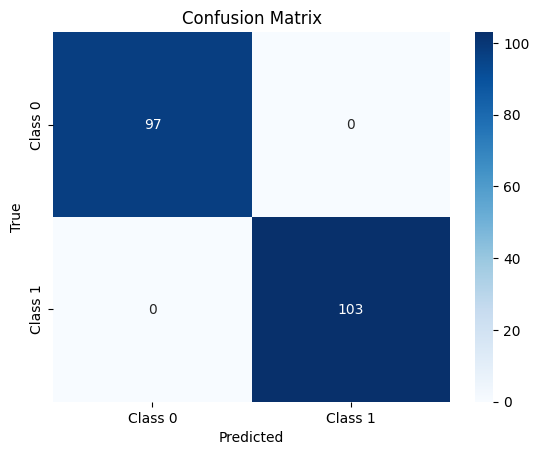

In [ ]:
# Install keras-tuner if needed
!pip install -q keras-tuner

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate synthetic data with clear class difference
def generate_better_synthetic_data(num_samples=1000, image_shape=(128, 128, 3)):
    half = num_samples // 2
    X0 = np.random.rand(half, *image_shape) * 0.3  # Darker images
    y0 = np.zeros(half, dtype=int)

    X1 = np.random.rand(half, *image_shape) * 0.7 + 0.3  # Brighter images
    y1 = np.ones(half, dtype=int)

    X = np.concatenate([X0, X1], axis=0)
    y = np.concatenate([y0, y1], axis=0)

    indices = np.random.permutation(num_samples)
    return X[indices].astype(np.float32), y[indices]

# 2. Define Attention Block (channel-wise attention over spatial features)
def attention_block(feature_map):
    # shape: (batch_size, height, width, channels)
    attention = layers.GlobalAveragePooling2D()(feature_map)
    attention = layers.Dense(feature_map.shape[-1], activation='sigmoid')(attention)
    attention = layers.Reshape((1, 1, feature_map.shape[-1]))(attention)
    return layers.Multiply()([feature_map, attention])

# 3. Build CNN + Attention model
def build_cnn_attention_model(input_shape):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    # Attention applied to last CNN feature map
    x = attention_block(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, activation="sigmoid")(x)

    return models.Model(inputs, output)

# 4. Prepare data
input_shape = (128, 128, 3)
X, y = generate_better_synthetic_data(1000, input_shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Build and train model
model = build_cnn_attention_model(input_shape)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

# 6. Predict and evaluate
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# 7. Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Class 0", "Class 1"]))
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# 8. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
!pip install -q keras-tuner

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# ------------------------------
# CNN Feature Extractor
# ------------------------------
def build_cnn_model(input_shape):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.GlobalAveragePooling2D()(x)  # Output shape: (None, 128)
    return models.Model(inputs, x, name="CNN_Model")

# ------------------------------
# Attention Mechanism
# ------------------------------
def attention_block(inputs):
    # Compute attention scores over features
    attention_scores = layers.Dense(inputs.shape[-1], activation="tanh")(inputs)
    attention_scores = layers.Softmax()(attention_scores)
    attention_output = layers.Multiply()([inputs, attention_scores])
    return attention_output

# ------------------------------
# CNN + Attention Model
# ------------------------------
def build_cnn_attention_model(input_shape, num_classes):
    cnn_model = build_cnn_model(input_shape)

    # Apply Attention Mechanism
    attention_output = attention_block(cnn_model.output)

    # Fully Connected Layers
    x = layers.Dense(64, activation="relu")(attention_output)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(num_classes, activation="softmax")(x)

    # Define Model
    model = models.Model(inputs=cnn_model.input, outputs=output, name="CNN_Attention_Model")
    return model

# ------------------------------
# Define input shape and number of classes
# ------------------------------
input_shape = (128, 128, 3)
num_classes = 2

# Build and compile the model
cnn_attention_model = build_cnn_attention_model(input_shape, num_classes)
cnn_attention_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
cnn_attention_model.summary()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 10.1 MB/s eta 0:00:00


Model: "CNN_Attention_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_2[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 128)       │          0 │ global_average_p… │
│                     │                   │            │ softmax[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 2)         │        130 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 118,146 (461.51 KB)

 Trainable params: 118,146 (461.51 KB)

 Non-trainable params: 0 (0.00 B)